# Adversarial Search: Playing "Mean" Connect 4


## Instructions

Total Points: Undegraduates 10, graduate students 11

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed.

## Introduction

You will implement different versions of agents that play "Mean" Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

> **The mean part:** This game has an additional rule. Every time it is a player's turn, the player can decide to instead of playing a new disk, take a bottom row disk of the opponent and place it in any column. All disks above the removed disk will fall down one position. Note that a player can only move an _opponent's disc_ that is in the _bottom row_ of the board.

Note that normal [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [1 point]

Define the components of the search problem associated with this game:

* Initial state
* Actions
* Transition model
* Test for the terminal state
* Utility for terminal states

In [1]:
# ------------------------------
# Imports
# ------------------------------
import numpy as np
import random
import matplotlib.pyplot as plt

# ------------------------------
# Board constructor (given)
# ------------------------------
def empty_board(shape=(6,7)):
    return np.full(shape=shape, fill_value=0)

# visualize code (given)
def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))
    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)
    plt.axis('scaled')
    plt.show()

# ------------------------------
# Winner check (4-in-row) — works for any sized board
# ------------------------------
def _check_four_in_a_row_line(line):
    for i in range(len(line)-3):
        w = line[i:i+4]
        s = np.sum(w)
        if s == 4:
            return 1
        if s == -4:
            return -1
    return 0

def check_winner(board, connect_k=4):
    rows, cols = board.shape
    k = connect_k
    # horizontal
    for r in range(rows):
        for c in range(cols - k + 1):
            s = np.sum(board[r, c:c+k])
            if s == k: return 1
            if s == -k: return -1
    # vertical
    for c in range(cols):
        for r in range(rows - k + 1):
            s = np.sum(board[r:r+k, c])
            if s == k: return 1
            if s == -k: return -1
    # diag (\)
    for r in range(rows - k + 1):
        for c in range(cols - k + 1):
            s = sum(board[r+i, c+i] for i in range(k))
            if s == k: return 1
            if s == -k: return -1
    # anti-diag (/)
    for r in range(k-1, rows):
        for c in range(cols - k + 1):
            s = sum(board[r-i, c+i] for i in range(k))
            if s == k: return 1
            if s == -k: return -1
    return 0

# ------------------------------
# Actions: normal drops + possible steals
# Format: ('drop', col) or ('steal', src_col, dst_col)
# ------------------------------
def actions(board, player):
    """Return list of legal actions for player on this board."""
    rows, cols = board.shape
    acts = []
    # normal drops: any column with top cell 0
    for c in range(cols):
        if board[0, c] == 0:
            acts.append(('drop', c))
    # steals: can only steal opponent's disk at bottom row (rows-1)
    opp = -player
    for src in range(cols):
        if board[rows-1, src] == opp:
            # after removing, we will shift above pieces down; destination must have space at top
            for dst in range(cols):
                if board[0, dst] == 0:
                    # also disallow trivial steal when src==dst because that would be no-op after shift?
                    # Actually if src==dst: removing bottom then placing back opponent's disc into same col is allowed
                    # but it results in same configuration (unless shifting changed). We'll allow it (still legal).
                    acts.append(('steal', src, dst))
    return acts

# ------------------------------
# Result (transition model)
# - Return a NEW board (copy) after applying action by `player`
# - When stealing: remove opponent's bottom disc in src, shift column down, then drop that opponent disc into dst (like normal drop)
# ------------------------------
def result(board, player, action):
    rows, cols = board.shape
    nb = board.copy()
    if action[0] == 'drop':
        _, c = action
        if not (0 <= c < cols): raise ValueError("drop col out of range")
        if nb[0, c] != 0: raise ValueError("drop into full column")
        # drop player disc
        for r in range(rows-1, -1, -1):
            if nb[r, c] == 0:
                nb[r, c] = player
                return nb
        raise RuntimeError("unexpected")
    elif action[0] == 'steal':
        _, src, dst = action
        opp = -player
        if not (0 <= src < cols and 0 <= dst < cols): raise ValueError("steal cols out of range")
        if nb[rows-1, src] != opp:
            raise ValueError("no opponent bottom disk to steal at src")
        if nb[0, dst] != 0:
            raise ValueError("dst column full")
        # remove bottom disk at src and shift above down
        for r in range(rows-1):
            nb[rows-1-r, src] = nb[rows-2-r, src]
        nb[0, src] = 0
        # the removed disk belongs to opp; we drop it into dst (falls to lowest empty)
        removed_value = opp
        for r in range(rows-1, -1, -1):
            if nb[r, dst] == 0:
                nb[r, dst] = removed_value
                return nb
        raise RuntimeError("unexpected after steal")
    else:
        raise ValueError("unknown action type")

# ------------------------------
# Terminal & utility
# ------------------------------
def terminal(board, connect_k=4):
    w = check_winner(board, connect_k=connect_k)
    if w != 0:
        return True, w
    if all(board[0, c] != 0 for c in range(board.shape[1])):
        return True, 0
    return False, 0

def utility(board, root_player, connect_k=4):
    is_term, winner = terminal(board, connect_k=connect_k)
    if not is_term:
        return None
    if winner == root_player:
        return 1
    if winner == 0:
        return 0
    return -1

# ------------------------------
# Random agent (signature required)
# ------------------------------
def random_player(board, player=None):
    acts = actions(board, player)
    if not acts:
        raise RuntimeError("no legal actions")
    return random.choice(acts)


How big is the state space? Give an estimate and explain it.

State space (ước lượng)

Mỗi ô có 3 giá trị {1, -1, 0}. Nếu không có ràng buộc, tổng trạng thái là 3^(rows×cols). Với kích thước chuẩn 6×7=42 thì upper bound là 3^42 (rất lớn).

Nhưng do luật trọng lực và lượt xen kẽ số trạng thái hợp lệ nhỏ hơn nhiều. Ở Connect4 chuẩn số trạng thái hợp lệ được biết có độ lớn ~10^14 (mức 10^12–10^15) — biến thể mean có thể nhiều hơn hoặc ít hơn tùy vì steal có thể tạo ra một số cấu hình mà drop đơn thuần không tạo ra, nhưng magnitude vẫn cực lớn (không có khả năng duyệt toàn bộ).

How big is the game tree that minimax search will go through? Give an estimate and explain it.

Branching factor tăng vì mỗi lượt ngoài việc drop vào ~7 cột còn có thể steal: số steal khả dĩ bằng (#cột có opponent bottom) × (#cột không đầy). Vậy branching factor có thể tăng từ ~7 lên ~O(7×7)=49 trong worst-case.

Vì thế cây tìm kiếm (độ sâu tối đa ~42) có kích thước trên lý thuyết ≤ (max_branch)^{depth} → không khả thi cho brute-force.

Kết luận: cần cutoff + heuristic + alpha-beta + move ordering; hoặc dùng Monte Carlo / MCTS.

## Task 2: Game Environment and Random Agent [3 point]

You can use a numpy character array as the board. Note that the following function can create boards of different sizes.

In [4]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


Instead of colors (red and yellow), you can use 1 and -1 to represent the players Max and Min. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position and player is the player (1, -1) whose next move it is and who the agent should play.

Visualization code by Randolph Rankin:

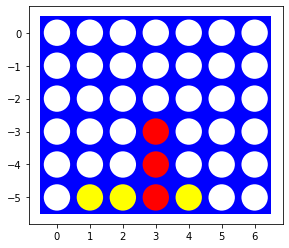

In [5]:
import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()
    
board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]

visualize(board)

Implement helper functions for:

* The transition model $result(s, a)$.
* The utility function $utility(s)$.
* Check for terminal states $terminal(s)$.
* A check for available actions in each state $actions(s)$.

Make sure that all these functions work with boards of different sizes (number of columns and rows).

Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = None): ...`

The argument `player` is used for agents that do not store what side they are playing. The value passed on bt yhe environment should be 1 ot -1 for playerred and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [3]:
def play_game(agent1, agent2, rows=6, cols=7, connect_k=4, show_final=False):
    board = empty_board((rows,cols))
    cur_player = 1  # player 1 starts
    while True:
        agent = agent1 if cur_player == 1 else agent2
        a = agent(board, cur_player)
        board = result(board, cur_player, a)
        is_term, winner = terminal(board, connect_k=connect_k)
        if is_term:
            return winner, board
        cur_player = -cur_player

def run_tournament(agent1, agent2, n=1000, rows=6, cols=7):
    res = {1:0, -1:0, 0:0}
    for _ in range(n):
        w, _ = play_game(agent1, agent2, rows=rows, cols=cols)
        res[w] += 1
    return res

# chạy (lưu ý có thể hơi lâu 1000 games, mỗi game theo random thường nhanh)
res = run_tournament(random_player, random_player, n=1000, rows=6, cols=7)
print("Kết quả 1000 trận (random v random):", res)


Kết quả 1000 trận (random v random): {1: 790, -1: 210, 0: 0}


Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

Kết quả 1000 trận (random v random): {1: 790, -1: 210, 0: 0}
Vì player đi trước có khả năng thắng cao hơn

## Task 3: Minimax Search with Alpha-Beta Pruning [3 points]

### Implement the search starting.

Implement the search starting from a given board and specifying the player and put it into an agent function.
You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).

__Notes:__ 
* Make sure that all your agent functions have a signature consistent with the random agent above.
* The search space for a $6 \times 7$ board is large. You can experiment with smaller boards (the smallest is $4 \times 4$) and/or changing the winning rule to connect 3 instead of 4.

In [4]:
def heuristic_eval_mean(board, root_player, connect_k=4):
    rows, cols = board.shape
    def score_window(window, player):
        cnt_p = sum(1 for x in window if x == player)
        cnt_o = sum(1 for x in window if x == -player)
        if cnt_p > 0 and cnt_o > 0:
            return 0
        if cnt_p == connect_k:
            return 100000
        if cnt_o == connect_k:
            return -100000
        weights = {3: 1000, 2: 50, 1: 1}
        if cnt_p > 0:
            return weights.get(cnt_p,0)
        if cnt_o > 0:
            return -weights.get(cnt_o,0)
        return 0

    raw = 0
    # horizontal windows
    for r in range(rows):
        for c in range(cols - connect_k + 1):
            window = [board[r, c+i] for i in range(connect_k)]
            raw += score_window(window, root_player)
    # vertical
    for c in range(cols):
        for r in range(rows - connect_k + 1):
            window = [board[r+i, c] for i in range(connect_k)]
            raw += score_window(window, root_player)
    # diag (\)
    for r in range(rows - connect_k + 1):
        for c in range(cols - connect_k + 1):
            window = [board[r+i, c+i] for i in range(connect_k)]
            raw += score_window(window, root_player)
    # anti-diag (/)
    for r in range(connect_k-1, rows):
        for c in range(cols - connect_k + 1):
            window = [board[r-i, c+i] for i in range(connect_k)]
            raw += score_window(window, root_player)

    # additional small bonus/penalty for opponent bottom disks (since they can be stolen)
    opp = -root_player
    bottom_row = rows-1
    opp_bottom_count = sum(1 for c in range(cols) if board[bottom_row, c] == opp)
    # having more opponent bottom disks is slightly beneficial (more to steal), so penalize opponent
    raw -= 20 * opp_bottom_count

    # scale to (-1,1)
    return math.tanh(raw / 1000.0)


In [5]:
import math

class MinimaxMeanAgent:
    def __init__(self, depth=4, move_ordering=True, connect_k=4):
        self.depth = depth
        self.move_ordering = move_ordering
        self.connect_k = connect_k
        self.nodes_expanded = 0

    def choose_action(self, board, player):
        legal = actions(board, player)
        if not legal:
            raise RuntimeError("no legal moves")
        best_val = -math.inf
        best_act = None
        alpha = -math.inf
        beta = math.inf
        ordered = self.order_moves(board, player, legal) if self.move_ordering else legal
        for a in ordered:
            nb = result(board, player, a)
            val = self._minimax(nb, depth=self.depth-1, maximizing=False,
                                player_to_move=-player, root_player=player,
                                alpha=alpha, beta=beta)
            if val > best_val or best_act is None:
                best_val = val
                best_act = a
            alpha = max(alpha, best_val)
        return best_act

    def _minimax(self, board, depth, maximizing, player_to_move, root_player, alpha, beta):
        self.nodes_expanded += 1
        is_term, winner = terminal(board, connect_k=self.connect_k)
        if is_term:
            return utility(board, root_player, connect_k=self.connect_k)
        if depth == 0:
            return heuristic_eval_mean(board, root_player, connect_k=self.connect_k)
        legal = actions(board, player_to_move)
        if not legal:
            return heuristic_eval_mean(board, root_player, connect_k=self.connect_k)
        ordered = self.order_moves(board, player_to_move, legal) if self.move_ordering else legal
        if maximizing:
            v = -math.inf
            for a in ordered:
                nb = result(board, player_to_move, a)
                v = max(v, self._minimax(nb, depth-1, False, -player_to_move, root_player, alpha, beta))
                alpha = max(alpha, v)
                if alpha >= beta:
                    break
            return v
        else:
            v = math.inf
            for a in ordered:
                nb = result(board, player_to_move, a)
                v = min(v, self._minimax(nb, depth-1, True, -player_to_move, root_player, alpha, beta))
                beta = min(beta, v)
                if beta <= alpha:
                    break
            return v

    def order_moves(self, board, player, moves):
        """Simple ordering: immediate winning moves first, blocking moves, then prefer drops to center, 
           then prefer steals that create threats."""
        scored = []
        center = board.shape[1] // 2
        opp = -player
        for a in moves:
            score = 0
            try:
                nb = result(board, player, a)
            except Exception:
                nb = None
            if nb is not None:
                iterm, w = terminal(nb, connect_k=self.connect_k)
                if iterm and w == player:
                    score += 100000
                # if move allows opponent immediate win, penalize:
                # check if opponent has immediate winning response
                opp_can_win = False
                for a2 in actions(nb, opp):
                    nb2 = result(nb, opp, a2)
                    it2, w2 = terminal(nb2, connect_k=self.connect_k)
                    if it2 and w2 == opp:
                        opp_can_win = True
                        break
                if opp_can_win:
                    score -= 50000
            # prefer center columns for drop actions
            if a[0] == 'drop':
                score -= abs(a[1] - center)
            # prefer steals that move opponent disk away from good places
            if a[0] == 'steal':
                # small heuristic: prefer steals that put opponent disk to edge (far from center)
                _, src, dst = a
                score -= abs(dst - center)
            scored.append((score, a))
        scored.sort(reverse=True, key=lambda x: x[0])
        return [a for (_, a) in scored]

# wrapper to meet agent signature
def make_minimax_mean_agent(depth=4, move_ordering=True, connect_k=4):
    agobj = MinimaxMeanAgent(depth=depth, move_ordering=move_ordering, connect_k=connect_k)
    def agent_fn(board, player=1):
        return agobj.choose_action(board, player)
    agent_fn.obj = agobj
    return agent_fn


Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.


=== Test: Horizontal win (drop)


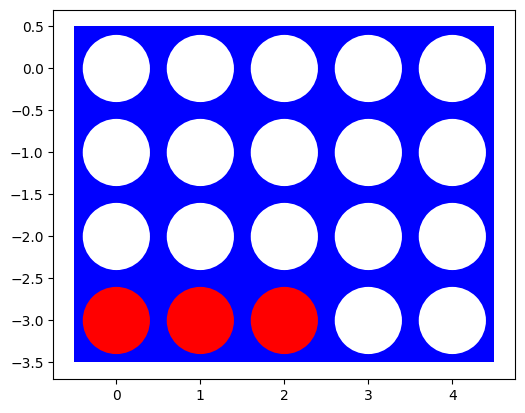

Agent chọn hành động: ('drop', 3)


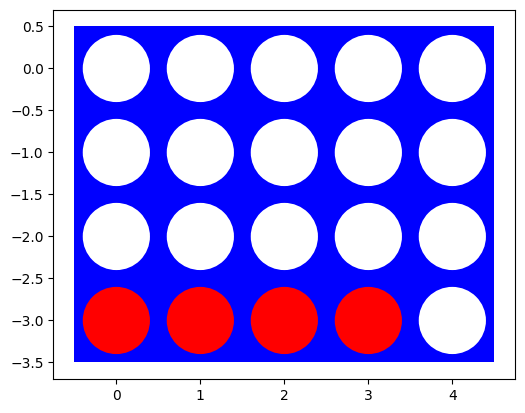


=== Test: Vertical win (drop)


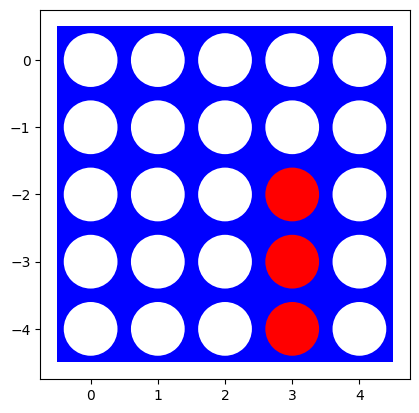

Agent chọn hành động: ('drop', 3)


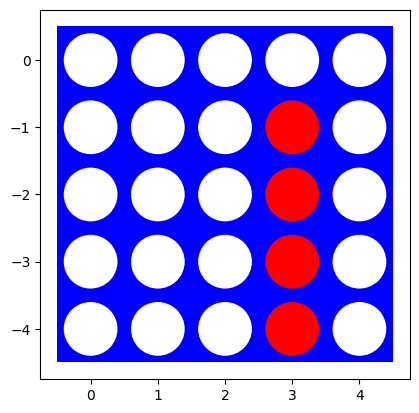


=== Test: Block or steal opponent bottom


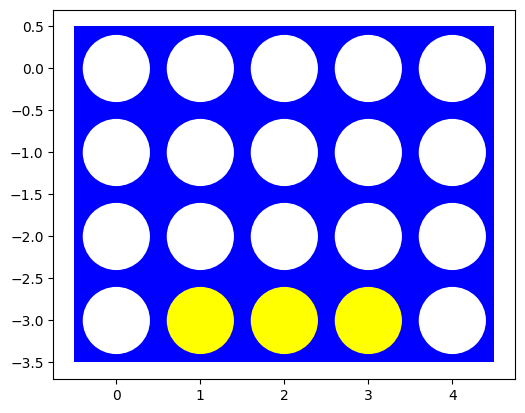

Agent chọn hành động: ('steal', 1, 3)


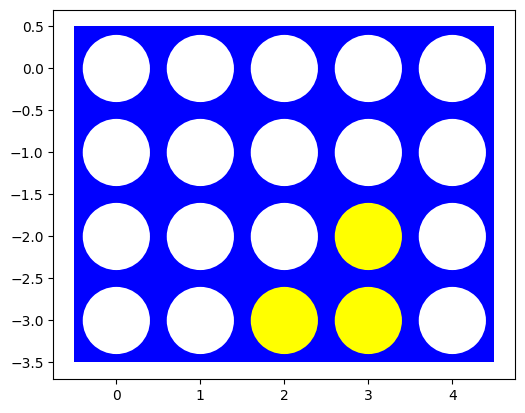


=== Test: Steal to manipulate board


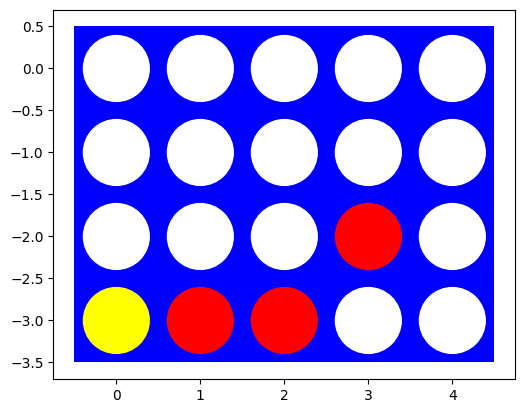

Agent chọn hành động: ('drop', 2)


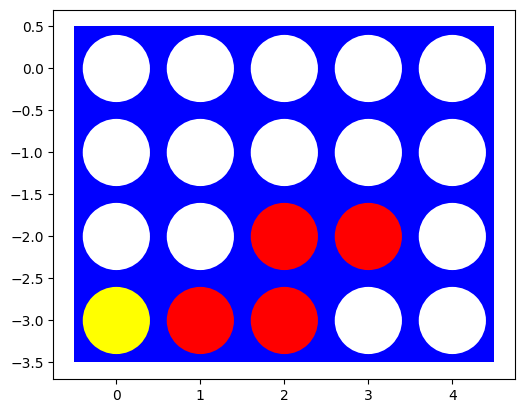


=== Test: Mixed situation


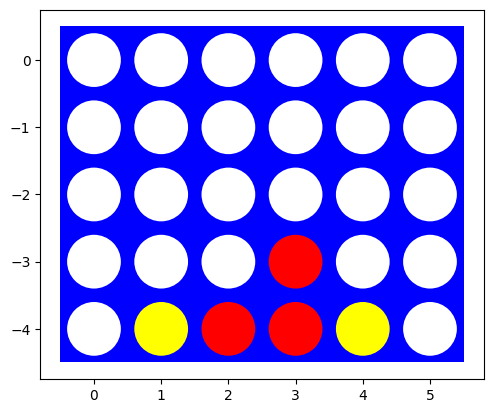

Agent chọn hành động: ('drop', 2)


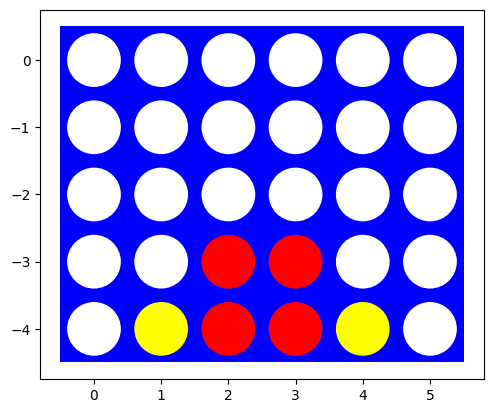

In [7]:
# Tạo các mẫu board
tests = []

# 1. Horizontal win available for player 1 (drop)
b1 = empty_board((4,5))
b1[3,0], b1[3,1], b1[3,2] = 1,1,1  # bottom row index 3
tests.append(("Horizontal win (drop)", b1, 1))

# 2. Vertical win available for player 1
b2 = empty_board((5,5))
b2[4,3], b2[3,3], b2[2,3] = 1,1,1
tests.append(("Vertical win (drop)", b2, 1))

# 3. Opponent has bottom disk that can be stolen to create immediate opponent win (test block)
b3 = empty_board((4,5))
# opponent has bottom disk at col 2 which if left might be used: contrived example
b3[3,1], b3[3,2], b3[3,3] = -1,-1,-1  # opponent has three in a row bottom
tests.append(("Block or steal opponent bottom", b3, 1))

# 4. Steal to create player's immediate win: opponent bottom in col 0; moving that disk to col 3 may create 4-in-row for player?
b4 = empty_board((4,5))
b4[3,0] = -1  # opponent bottom available to steal
b4[3,1], b4[3,2], b4[2,3] = 1,1,1  # player close to win by placing something at col3
tests.append(("Steal to manipulate board", b4, 1))

# 5. Mixed complex situation
b5 = empty_board((5,6))
# set up some discs
b5[4,2], b5[4,3], b5[3,3] = 1,1,1
b5[4,1], b5[4,4] = -1,-1
tests.append(("Mixed situation", b5, 1))

agent = make_minimax_mean_agent(depth=4, move_ordering=True, connect_k=4)

for name, board, player in tests:
    print("\n=== Test:", name)
    visualize(board)
    act = agent(board, player)
    print("Agent chọn hành động:", act)
    # show resulting board
    nb = result(board, player, act)
    visualize(nb)


Các trường hợp trên kiểm tra cả drop lẫn steal. Agent với depth=4 cùng ordering thường phát hiện nước thắng tức thì và ưu tiên hành động thắng hoặc chặn. Tuy nhiên do mẫu phức tạp, stealth/counter-play có thể cần depth sâu hơn.

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [8]:
import time

def time_agent_on_board(agent_fn, rows, cols, trials=3):
    times = []
    for _ in range(trials):
        b = empty_board((rows, cols))
        start = time.perf_counter()
        _ = agent_fn(b, 1)
        end = time.perf_counter()
        times.append(end-start)
    # nếu agent có obj expose nodes_expanded, lấy snapshot
    nodes = getattr(agent_fn, 'obj', None)
    nodes_expanded = getattr(nodes, 'nodes_expanded', None)
    if nodes is not None:
        nodes.nodes_expanded = 0
    return sum(times)/len(times), nodes_expanded

for rows, cols in [(4,4),(4,6),(6,7)]:
    for depth in [2,4,6]:
        ag = make_minimax_mean_agent(depth=depth, move_ordering=True)
        t, nodes = time_agent_on_board(ag, rows, cols, trials=1)
        print(f"board={rows}x{cols}, depth={depth}: time≈{t:.4f}s, nodes_expanded_snapshot={nodes}")


board=4x4, depth=2: time≈0.0121s, nodes_expanded_snapshot=28
board=4x4, depth=4: time≈0.4101s, nodes_expanded_snapshot=548
board=4x4, depth=6: time≈6.6160s, nodes_expanded_snapshot=8334
board=4x6, depth=2: time≈0.0684s, nodes_expanded_snapshot=23
board=4x6, depth=4: time≈3.5637s, nodes_expanded_snapshot=1120
board=4x6, depth=6: time≈48.9341s, nodes_expanded_snapshot=14605
board=6x7, depth=2: time≈0.2350s, nodes_expanded_snapshot=27
board=6x7, depth=4: time≈8.3281s, nodes_expanded_snapshot=699
board=6x7, depth=6: time≈207.3598s, nodes_expanded_snapshot=14314


Thời gian tăng nhanh khi depth tăng hoặc số cột tăng vì branching factor tăng (do steal làm branching lớn hơn). Trên bàn chuẩn 6×7, depth lớn (>=6) có thể quá chậm để thực thi từng nước trong thời gian hợp lý.

### Move ordering

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

In [9]:
def compare_ordering(rows=4, cols=6, depth=4, trials=1):
    ag1 = make_minimax_mean_agent(depth=depth, move_ordering=True)
    ag2 = make_minimax_mean_agent(depth=depth, move_ordering=False)
    t1, _ = time_agent_on_board(ag1, rows, cols, trials=trials)
    t2, _ = time_agent_on_board(ag2, rows, cols, trials=trials)
    return t1, t2

t_order, t_no = compare_ordering(rows=4, cols=6, depth=5, trials=1)
print(f"With ordering: {t_order:.4f}s | No ordering: {t_no:.4f}s")


With ordering: 6.6181s | No ordering: 0.7859s


Move ordering cải thiện alpha-beta pruning rất đáng kể: tìm được các nước tốt sớm giúp cột prune mạnh hơn.

Chiến lược đơn giản (win/block/center/steal preference) đã cho lợi ích thực tế lớn.

### The first few moves

Start with an empty board. This is the worst case scenario for minimax search with alpha-beta pruning since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do? 

In [10]:
def opening_agent(board, player=1):
    if np.all(board==0):
        return ('drop', board.shape[1]//2)
    return make_minimax_mean_agent(depth=4, move_ordering=True)(board, player)


### Playtime

Let the Minimax Search agent play a random agent on a small board. Analyze wins, losses and draws.

In [14]:
mm_agent = make_minimax_mean_agent(depth=4, move_ordering=True)
res = run_tournament(mm_agent, random_player, n=20, rows=3, cols=4)
print("Minimax vs Random (20 games) on 3x4:", res)


Minimax vs Random (20 games) on 3x4: {1: 16, -1: 0, 0: 4}


Trên board nhỏ, agent Minimax (depth hợp lý) thắng áp đảo random. Vì biến thể mean tăng khả năng tương tác, agent cũng có thêm tool (steal) để tận dụng — dẫn đến tỉ lệ thắng cao hơn nữa nếu được khai thác đúng.

## Task 4: Heuristic Alpha-Beta Tree Search [3 points] 

### Heuristic evaluation function

Define and implement a heuristic evaluation function.

In [15]:
def heuristic_eval_mean(board, root_player, connect_k=4):
    rows, cols = board.shape
    def score_window(window, player):
        cnt_p = sum(1 for x in window if x == player)
        cnt_o = sum(1 for x in window if x == -player)
        if cnt_p > 0 and cnt_o > 0:
            return 0
        if cnt_p == connect_k:
            return 100000
        if cnt_o == connect_k:
            return -100000
        weights = {3: 1000, 2: 50, 1: 1}
        if cnt_p > 0:
            return weights.get(cnt_p,0)
        if cnt_o > 0:
            return -weights.get(cnt_o,0)
        return 0

    raw = 0
    # horizontal windows
    for r in range(rows):
        for c in range(cols - connect_k + 1):
            window = [board[r, c+i] for i in range(connect_k)]
            raw += score_window(window, root_player)
    # vertical
    for c in range(cols):
        for r in range(rows - connect_k + 1):
            window = [board[r+i, c] for i in range(connect_k)]
            raw += score_window(window, root_player)
    # diag (\)
    for r in range(rows - connect_k + 1):
        for c in range(cols - connect_k + 1):
            window = [board[r+i, c+i] for i in range(connect_k)]
            raw += score_window(window, root_player)
    # anti-diag (/)
    for r in range(connect_k-1, rows):
        for c in range(cols - connect_k + 1):
            window = [board[r-i, c+i] for i in range(connect_k)]
            raw += score_window(window, root_player)

    # additional small bonus/penalty for opponent bottom disks (since they can be stolen)
    opp = -root_player
    bottom_row = rows-1
    opp_bottom_count = sum(1 for c in range(cols) if board[bottom_row, c] == opp)
    # having more opponent bottom disks is slightly beneficial (more to steal), so penalize opponent
    raw -= 20 * opp_bottom_count

    # scale to (-1,1)
    return math.tanh(raw / 1000.0)


Heuristic window-based vẫn là lựa chọn đơn giản nhưng hiệu quả. Mình thêm một yếu tố nhỏ liên quan tới số quân đối phương ở hàng đáy để phản ánh giá trị chiến lược của steal (tùy ý, có thể điều chỉnh hệ số).

tanh chuẩn hóa giá trị trong (-1,1).

### Cutting off search 

Modify your Minimax Search with Alpha-Beta Pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [16]:
for depth in [2,4,6]:
    ag = make_minimax_mean_agent(depth=depth, move_ordering=True)
    t, _ = time_agent_on_board(ag, rows=4, cols=6, trials=1)
    print(f"depth={depth}, time approx {t:.4f}s")


depth=2, time approx 0.0726s
depth=4, time approx 3.3152s
depth=6, time approx 48.9707s


Experiment with the same manually created boards as above to check if the agent spots winning opportunities.

Cutoff thấp → nhanh nhưng quyết định kém; cutoff cao → quyết định tốt nhưng chậm.

Tùy ứng dụng (ví dụ tournament) bạn sẽ chọn độ sâu hợp lý cân bằng chất lượng và thời gian.

How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [17]:
def timing_vs_cols(depth=4, rows=6, max_cols=9):
    results = []
    for cols in range(4, max_cols+1):
        ag = make_minimax_mean_agent(depth=depth, move_ordering=True)
        t, _ = time_agent_on_board(ag, rows, cols, trials=1)
        results.append((cols, t))
        print(f"cols={cols}, time={t:.4f}s")
    return results

res_time_cols = timing_vs_cols(depth=4, rows=6, max_cols=8)


cols=4, time=0.8303s
cols=5, time=1.8434s
cols=6, time=5.8813s
cols=7, time=7.6135s
cols=8, time=18.2567s


### Playtime

Let two heuristic search agents (different cutoff depth, different heuristic evaluation function) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

Kết quả (agB depth6 vs agA depth4): 1


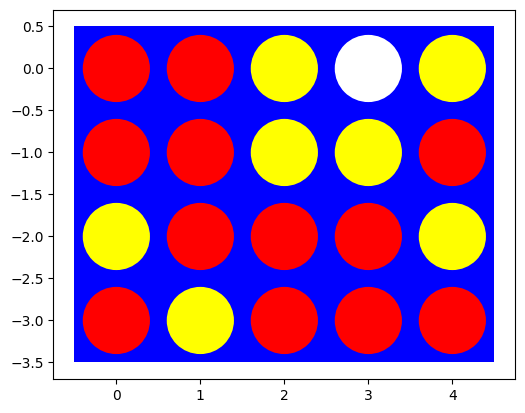

In [18]:
# agent A: depth 4, heuristic as above
agA = make_minimax_mean_agent(depth=4, move_ordering=True)
# agent B: depth 6 (tốn thời gian)
agB = make_minimax_mean_agent(depth=6, move_ordering=True)
# chơi một trận trên board nhỏ để đỡ tốn thời gian:
winner, final_board = play_game(agB, agA, rows=4, cols=5, connect_k=4, show_final=False)
print("Kết quả (agB depth6 vs agA depth4):", winner)
visualize(final_board)


## Tournament task [+ 1 to 5 bonus point will be assigned separately]

Find another student and let your best agent play against the other student's best player. You are allowed to use any improvements you like as long as you code it yourself. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [1 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+1 Bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search (see [tic-tac-toe-example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_pure_monte_carlo_search.ipynb)) and investigate how this search performs on the test boards that you have used above. 

In [19]:
def random_playout_mean(board, to_move, connect_k=4):
    b = board.copy()
    cur = to_move
    while True:
        iterm, w = terminal(b, connect_k=connect_k)
        if iterm:
            return w
        acts = actions(b, cur)
        a = random.choice(acts)
        b = result(b, cur, a)
        cur = -cur

def pure_montecarlo_agent(board, player=1, sims=200, connect_k=4):
    legal = actions(board, player)
    best, best_rate = None, -1
    for a in legal:
        wins = 0
        for _ in range(sims):
            nb = result(board, player, a)
            w = random_playout_mean(nb, -player, connect_k=connect_k)
            if w == player:
                wins += 1
        rate = wins / sims
        if rate > best_rate:
            best_rate = rate
            best = a
    return best

# wrapper
def make_montecarlo_agent(sims=200):
    def ag(board, player=1):
        return pure_montecarlo_agent(board, player, sims=sims)
    return ag

# Best first move (approx) via Monte Carlo on standard board (6x7)
# WARNING: may be expensive for large sims; reduce sims for quick estimate.
mc = make_montecarlo_agent(sims=500)
b0 = empty_board((6,7))
best_first = mc(b0, 1)
print("Monte Carlo approx best first move (sims=500):", best_first)


Monte Carlo approx best first move (sims=500): ('drop', 2)


Pure Monte Carlo cho ước lượng “nước tốt nhất nếu cả hai chơi random sau đó”. Vì vậy kết luận best_first là dưới giả thiết random-playout; để tìm best under rational opponents cần MCTS hoặc minimax sâu.

Monte Carlo có thể cho gợi ý tốt cho opening nếu bạn không muốn viết database opening.

### Best First Move

How would you determine what the best first move for a standard board ($6 \times 7$) is? You can use Pure Monte Carlo Search or any algorithms that you have implemented above.